In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def get_reduction_slope(initial_rate, target_rate, reduction_period):

    return -(initial_rate - target_rate) / reduction_period

# Source

## Data Sources
- [KEPCO Electricity Sales](https://epsis.kpx.or.kr/epsisnew/selectEksaAscAsuChart.do?menuId=060402)  
- [KOGAS Gas Sales](https://www.kogas.or.kr/site/koGas/1030304000000)  
- [KDHC Heat Sales](https://www.kdhc.co.kr/kdhc/bbs/B0000041/list.do?menuNo=200159)  
- Energy sales and reduction data were collected from the above sources, and reduction rates were calculated accordingly.
- Collected Dataset: `../resources/EERS.xlsx`

## Implemented Input Files
- `/input/policy/korea-2035/buildings/eers_cp.xml`  
- `/input/policy/korea-2035/buildings/eers_ep.xml`  
- `/input/policy/korea-2035/buildings/bld+_EE_technology.xml`

# Energy Efficiency Resource Standard

We first calculate the reduction rate trends for each energy type and assume that these trends continue through 2035.  
The method for implementing these reduction rates in the model follows Zhao et al. (2025).  
In the *Enhanced Policy* scenario, we assume that from 2030 onward, the incremental reduction rate doubles compared to the baseline trend.
Detailed implementation steps are provided below.

In [6]:
df = pd.read_excel("../resources/EERS.xlsx")
df

,Unnamed: 0,Heat Sales (Gcal),Electricity Sales (GWh),Gas Sales (Gcal),Gas Reduction (Gcal),Heat Reduction (Gcal),Electricity Reduction (GWh),heat reduction rate,electricity reduction rate,gas reduction rate
0,2018,14231852.00,526149.162000,474468900,NaN,NaN,183,NaN,0.000348,NaN
1,2019,13831229.00,520498.737726,440120700,28381.0,5446.0,324,0.000394,0.000622,0.000064
2,2020,14467218.00,509269.715000,424007700,25070.0,13035.0,279,0.000901,0.000548,0.000059
3,2021,14920380.00,533430.811000,483573400,6925.0,11893.0,372,0.000797,0.000697,0.000014
4,2022,15983983.00,547932.742213,503000700,4151.0,20616.0,501,0.001290,0.000914,0.000008
5,2023,14778725.77,545965.955350,453810200,34215.0,21779.0,837,0.001474,0.001533,0.000075


By 2023 KEPCO's reduction rate reaches 0.0015% and KDHC has similar reduction rate. KOGAS has a reduction rate of 1/20 compared to the others. Also, KEPCO plans to reach a reduction rate of 0.01 by 2031 (https://en.seoul.co.kr/news/publicnews/Public_IN/public-enterprise/2024/07/31/20240731012003). We assume KDHC has a similar target and KOGAS has target of 0.0005 (1/20 of those of KEPCO and KDHC) by 2031

In [7]:
elec_slope = get_reduction_slope(0.0015, 0.01, 8)
lstElec = list(df[(df['Unnamed: 0'] == 2020)]['electricity reduction rate'].values) + [0.0015 + elec_slope * i for i in range(2, 14, 5)]
lstElec

[np.float64(0.000547843297534392), 0.003625, 0.008937500000000001, 0.01425]

In [8]:

elec_2025 = 0.0015 + elec_slope * 2
elec_slope_eh = get_reduction_slope(elec_2025, 0.02, 6)
lstElecEh = list(df[(df['Unnamed: 0'] == 2020)]['electricity reduction rate'].values) + [elec_2025 + elec_slope_eh * i for i in range(0, 11, 5)] 
lstElecEh

[np.float64(0.000547843297534392),
 0.003625,
 0.017270833333333332,
 0.030916666666666665]

In [9]:
dfEE = pd.DataFrame({'Year': range(2020, 2040, 5), 'Current': lstElec, 'Enhanced': lstElecEh})
dfEE

,Year,Current,Enhanced
0,2020,0.000548,0.000548
1,2025,0.003625,0.003625
2,2030,0.008938,0.017271
3,2035,0.014250,0.030917


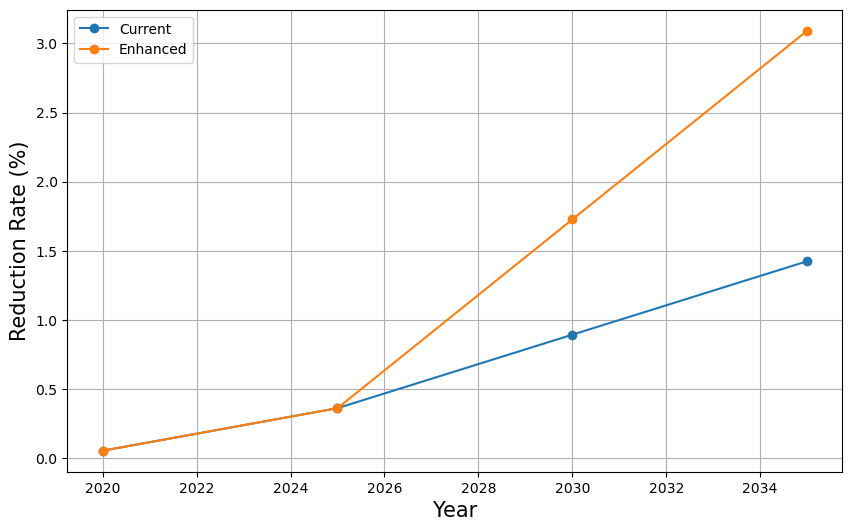

In [10]:
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dfEE['Year'], dfEE['Current'] * 100, label='Current', marker='o')
plt.plot(dfEE['Year'], dfEE['Enhanced'] * 100, label='Enhanced', marker='o')

# Add labels, title, and legend
plt.xlabel('Year', fontsize=15)
plt.ylabel('Reduction Rate (%)', fontsize=15)
# plt.title('Reduction Rates Over Time')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

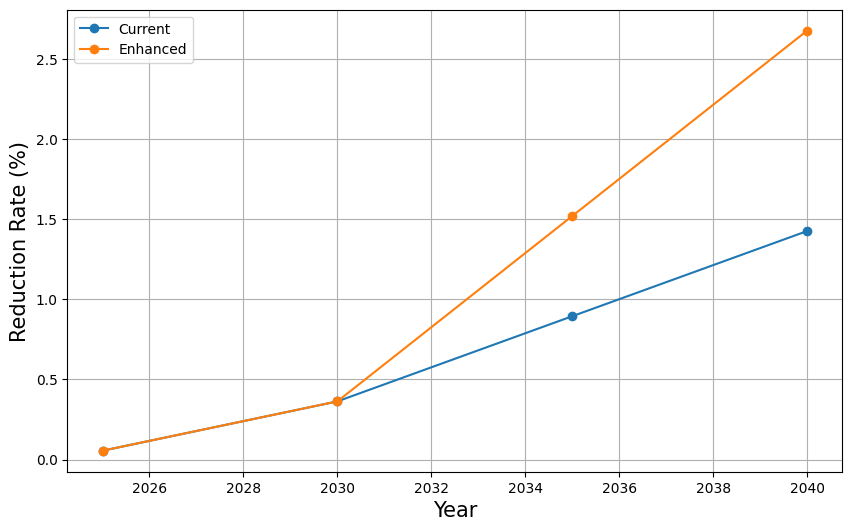

In [ ]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dfEE['Year'], dfEE['Current'] * 100, label='Current', marker='o')
plt.plot(dfEE['Year'], dfEE['Enhanced'] * 100, label='Enhanced', marker='o')

# Add labels, title, and legend
plt.xlabel('Year', fontsize=15)
plt.ylabel('Reduction Rate (%)', fontsize=15)
# plt.title('Reduction Rates Over Time')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [14]:
gas_slope = get_reduction_slope(0.000075, 0.0005, 11)
lstGas = list(df[(df['Unnamed: 0'] == 2020)]['gas reduction rate'].values) + [0.000075 + gas_slope * i for i in range(5, 16, 5)]
lstGas

[np.float64(5.912628473492345e-05),
 0.0002681818181818182,
 0.0004613636363636363,
 0.0006545454545454545]

In [15]:
gas_slope_eh = get_reduction_slope(0.000075, 0.001, 11)
gas_2025 = 0.000075 + gas_slope * 5
lstGasEh = list(df[(df['Unnamed: 0'] == 2020)]['gas reduction rate'].values) + [gas_2025 + gas_slope_eh * i for i in range(0, 11, 5)]
lstGasEh

[np.float64(5.912628473492345e-05),
 0.0002681818181818182,
 0.0006886363636363637,
 0.0011090909090909092]

In [16]:
dfEEGas = pd.DataFrame({'Year': range(2020, 2040, 5), 'Current': lstGas, 'Enhanced': lstGasEh})
dfEEGas

,Year,Current,Enhanced
0,2020,0.000059,0.000059
1,2025,0.000268,0.000268
2,2030,0.000461,0.000689
3,2035,0.000655,0.001109


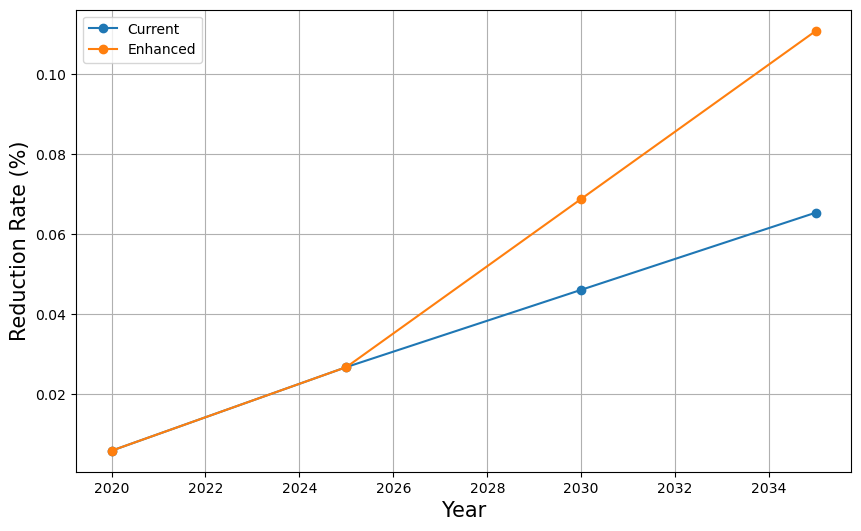

In [17]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dfEEGas['Year'], dfEEGas['Current'] * 100, label='Current', marker='o')
plt.plot(dfEEGas['Year'], dfEEGas['Enhanced'] * 100, label='Enhanced', marker='o')

# Add labels, title, and legend
plt.xlabel('Year', fontsize=15)
plt.ylabel('Reduction Rate (%)', fontsize=15)
# plt.title('Reduction Rates Over Time')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()